# Fig 3.03

Michaelis-Menten kinetics

In [1]:
using OrdinaryDiffEq
using ModelingToolkit
using Catalyst
using Plots
Plots.default(linewidth=2)

Reaction network

In [2]:
rn = @reaction_network begin
    (k1, km1), S + E <--> ES
    k2, ES --> E + P
end

Model ##ReactionSystem#238:
Unknowns (4): see unknowns(##ReactionSystem#238)
  S(t)
  E(t)
  ES(t)
  P(t)
Parameters (3): see parameters(##ReactionSystem#238)
  k1
  km1
  k2

In [3]:
setdefaults!(rn, [
    :S=>5.,
    :ES=>0.,
    :E=>1.,
    :P=>0.,
    :k1 => 30.,
    :km1 => 1.,
    :k2 => 10.,
])

osys = convert(ODESystem, rn; remove_conserved = true) |> structural_simplify

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


Model ##ReactionSystem#238:
Equations (2):
  2 standard: see equations(##ReactionSystem#238)
Unknowns (2): see unknowns(##ReactionSystem#238)
  S(t) [defaults to 5.0]
  E(t) [defaults to 1.0]
Parameters (5): see parameters(##ReactionSystem#238)
  k2 [defaults to 10.0]
  km1 [defaults to 1.0]
  Γ[1] [defaults to E(t) + ES(t)]
  Γ[2] [defaults to -E(t) + S(t) + P(t)]
  ⋮
Observed (2): see observed(##ReactionSystem#238)

In [4]:
observed(osys)

2-element Vector{Symbolics.Equation}:
 ES(t) ~ -E(t) + Γ[1]
 P(t) ~ E(t) - S(t) + Γ[2]

In [5]:
tend = 1.0

1.0

In [6]:
prob = ODEProblem(osys, [], tend)
sol = solve(prob)

┌ Warning: Initialization system is overdetermined. 2 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/CvDvM/src/systems/diffeqs/abstractodesystem.jl:1446


retcode: Success
Interpolation: 3rd order Hermite
t: 37-element Vector{Float64}:
 0.0
 0.006600703726699514
 0.01022277056012863
 0.015543467478140675
 0.02051947168533509
 0.02641018786018821
 0.03261917715421904
 0.03974230175678756
 0.04773168899544981
 0.0570841908779507
 ⋮
 0.6470324023587559
 0.6931031408477125
 0.7367683827322631
 0.7791059865493958
 0.8212466198548
 0.8642333668324144
 0.9090993660547448
 0.9568878660418696
 1.0
u: 37-element Vector{Vector{Float64}}:
 [5.0, 1.0]
 [4.395302952712936, 0.41804761979593485]
 [4.236279331946385, 0.2827770333522629]
 [4.091342551218703, 0.17911174466168772]
 [4.002950476488606, 0.1328519100257541]
 [3.9253138062440036, 0.10715692365888238]
 [3.8580005265583304, 0.09568932433965067]
 [3.788614104823388, 0.09092109954691635]
 [3.7148221391871394, 0.08982060235163533]
 [3.6304918096088126, 0.09058864991025088]
 ⋮
 [0.048403385343370596, 0.7252277328768327]
 [0.023100689055414694, 0.8069728851541076]
 [0.011833488316888048, 0.86638428121

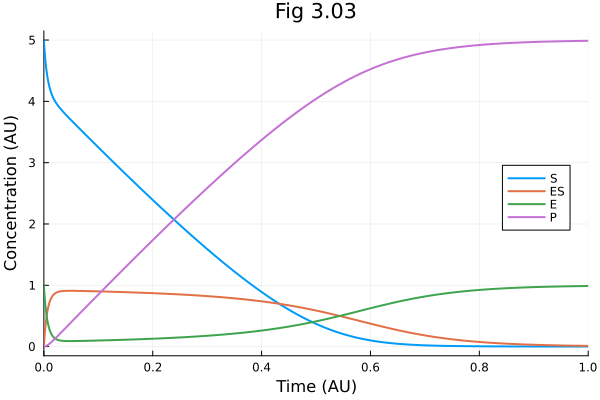

In [7]:
@unpack S, ES, E, P = osys
plot(sol, idxs=[S, ES, E, P], xlabel="Time (AU)", ylabel="Concentration (AU)", legend=:right, title="Fig 3.03")

In [8]:
rn303mm = @reaction_network begin
    mm(S, k2 * ET, (km1 + k2) / k1), S ⇒ P ## using \Rightarrow
end

Model ##ReactionSystem#247:
Unknowns (2): see unknowns(##ReactionSystem#247)
  S(t)
  P(t)
Parameters (4): see parameters(##ReactionSystem#247)
  k2
  ET
  km1
  k1

In [9]:
setdefaults!(rn303mm, [
    :S=>5.,
    :ET=>1.,
    :P=>0.,
    :k1 => 30.,
    :km1 => 1.,
    :k2 => 10.,
])

osysmm = convert(ODESystem, rn303mm; remove_conserved = true) |> structural_simplify

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


Model ##ReactionSystem#247:
Equations (1):
  1 standard: see equations(##ReactionSystem#247)
Unknowns (1): see unknowns(##ReactionSystem#247)
  S(t) [defaults to 5.0]
Parameters (5): see parameters(##ReactionSystem#247)
  k2 [defaults to 10.0]
  km1 [defaults to 1.0]
  Γ[1] [defaults to S(t) + P(t)]
  k1 [defaults to 30.0]
  ⋮
Observed (1): see observed(##ReactionSystem#247)

In [10]:
tend = 1.0
probmm = ODEProblem(osysmm, [], tend)
solmm = solve(probmm)

┌ Warning: Initialization system is overdetermined. 1 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/CvDvM/src/systems/diffeqs/abstractodesystem.jl:1446


retcode: Success
Interpolation: 3rd order Hermite
t: 15-element Vector{Float64}:
 0.0
 0.08829951015219592
 0.2967725537625472
 0.5000004875811703
 0.6196473972837556
 0.6670104453577671
 0.7099275100893456
 0.7465737578395125
 0.7827003202641042
 0.8170029171212273
 0.8515324938674043
 0.8866728375768105
 0.9240249128338719
 0.9646817216791721
 1.0
u: 15-element Vector{Vector{Float64}}:
 [5.0]
 [4.182468228248958]
 [2.3146741114200724]
 [0.7140966653045732]
 [0.13296502509374303]
 [0.0463025074968492]
 [0.01563176034250269]
 [0.005910624536905648]
 [0.002229911708642734]
 [0.0008784935038915187]
 [0.0003432013977878646]
 [0.00013175527102757403]
 [4.7615955140348484e-5]
 [1.5733007241347164e-5]
 [6.007498446700923e-6]

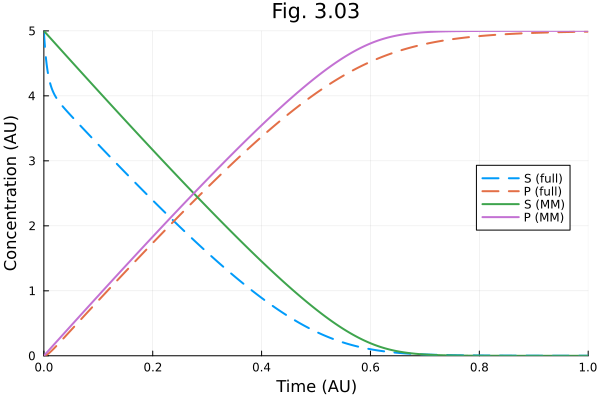

In [11]:
@unpack S, P = osys
fig = plot(sol, idxs=[S, P], line=(:dash), label=["S (full)" "P (full)"])
plot!(fig, solmm, idxs=[S, P], label=["S (MM)" "P (MM)"])
plot!(fig, title="Fig. 3.03",
    xlabel="Time (AU)", ylabel="Concentration (AU)",
    xlims=(0., tend), ylims=(0., 5.), legend=:right
)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*